# 03 — KNN Regressor

**TP Final · Aprendizaje de Máquina I (CEIA-FIUBA)** · Jaime Pinzón (a2629)

## Justificación del modelo (criterio oficial 5)

**Qué es.** K-Nearest Neighbors es un modelo **no paramétrico y basado en memoria**: para predecir la estadía de un paciente nuevo busca los $k$ encuentros más parecidos del train y promedia sus estadías (ponderadas o no por distancia). No asume ninguna forma funcional de la relación features→target.

**Por qué tiene sentido acá.** Es el contraste natural del baseline lineal del notebook 02: si pacientes "parecidos" (misma franja etaria, diagnósticos similares, misma carga de medicación y procedimientos) tienen estadías similares, KNN lo captura aunque la relación sea no lineal o local. Con 53.756 observaciones de train hay densidad suficiente para que el vecindario sea informativo.

**Qué exige de los datos — el escalado.** KNN decide TODO por distancias. Sin estandarizar, la distancia euclídea queda dominada por las variables de mayor rango: en nuestros datos `num_lab_procedures` va de 1 a 94 mientras `num_procedures` va de 0 a 5 — una diferencia de 10 procedimientos de laboratorio pesaría lo mismo que dos veces TODO el rango de procedimientos quirúrgicos, y los dummies de edad (0/1) serían casi invisibles. Por eso este pipeline usa `build_preprocessor(scale=True)`: el `StandardScaler` (fiteado por fold dentro del Pipeline) lleva todas las features a media 0 y desvío 1.

**Ventajas / desventajas frente a otras opciones.**
- ✅ Sin supuestos de forma funcional; captura no linealidades e interacciones locales "gratis"; un solo hiperparámetro dominante ($k$) fácil de interpretar (sesgo↑ con $k$↑, varianza↓).
- ❌ Costo de predicción alto (cada query busca en todo el train); sufre la maldición de la dimensionalidad (con 17 dimensiones todavía es razonable); sensible a features irrelevantes y a la escala (mitigado por la selección de AdD y el escalado).

**Hiperparámetros a explorar (D7 del plan):** grilla exhaustiva de `n_neighbors` × `weights` (uniform/distance) × `p` (1=Manhattan, 2=Euclídea). Optuna solo si el óptimo cae en un borde de la grilla.

In [1]:
import time

import pandas as pd
from sklearn.model_selection import KFold

from src.config import DIR_PROCESSED, SEED, TARGET
from src.evaluacion import evaluar, registrar
from src.pipelines import build_preprocessor

X_train = pd.read_parquet(DIR_PROCESSED / "X_train.parquet")
X_test = pd.read_parquet(DIR_PROCESSED / "X_test.parquet")
y_train = pd.read_parquet(DIR_PROCESSED / "y_train.parquet")[TARGET]
y_test = pd.read_parquet(DIR_PROCESSED / "y_test.parquet")[TARGET]

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"train: {X_train.shape} | test: {X_test.shape}")

train: (53756, 8) | test: (20354, 8)


In [2]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("preprocesador", build_preprocessor(scale=True)),
    ("modelo", KNeighborsRegressor(n_jobs=-1)),
])

grilla = {
    "modelo__n_neighbors": [3, 5, 10, 20, 40, 80, 160, 320],
    "modelo__weights": ["uniform", "distance"],
    "modelo__p": [1, 2],
}

busqueda = GridSearchCV(
    pipe, grilla, cv=cv, scoring="neg_mean_absolute_error",
    n_jobs=-1, refit=True, return_train_score=False,
)
t0 = time.perf_counter()
busqueda.fit(X_train, y_train)
t_busqueda = time.perf_counter() - t0

print(f"Busqueda: {len(busqueda.cv_results_['params'])} configuraciones x 5 folds "
      f"en {t_busqueda/60:.1f} min")
print(f"Mejor config: {busqueda.best_params_}")
print(f"MAE (CV) de la mejor config: {-busqueda.best_score_:.4f} dias")

Busqueda: 32 configuraciones x 5 folds en 3.3 min
Mejor config: {'modelo__n_neighbors': 80, 'modelo__p': 1, 'modelo__weights': 'distance'}
MAE (CV) de la mejor config: 1.6775 dias


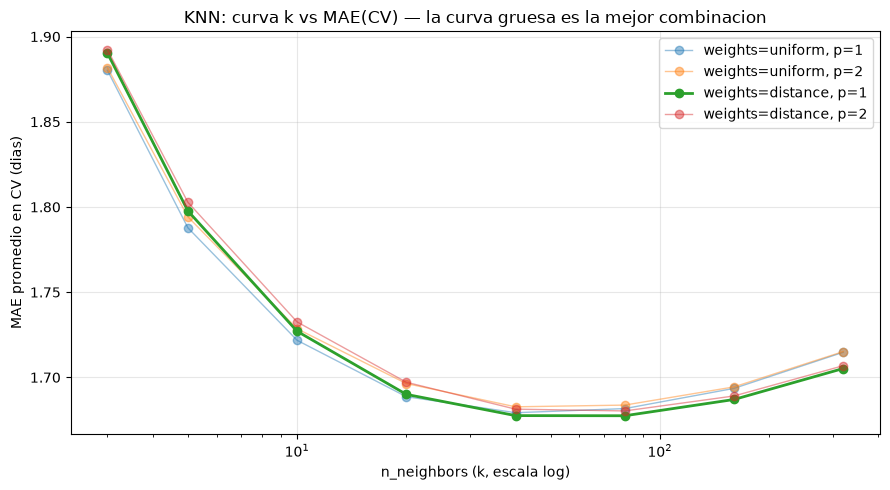

In [3]:
import matplotlib.pyplot as plt

resultados_cv = pd.DataFrame(busqueda.cv_results_)
mejor_w = busqueda.best_params_["modelo__weights"]
mejor_p = busqueda.best_params_["modelo__p"]

fig, ax = plt.subplots(figsize=(9, 5))
for w in ["uniform", "distance"]:
    for p in [1, 2]:
        sel = resultados_cv[
            (resultados_cv["param_modelo__weights"] == w)
            & (resultados_cv["param_modelo__p"] == p)
        ].sort_values("param_modelo__n_neighbors")
        ax.plot(
            sel["param_modelo__n_neighbors"], -sel["mean_test_score"],
            marker="o", linewidth=2 if (w == mejor_w and p == mejor_p) else 1,
            alpha=1.0 if (w == mejor_w and p == mejor_p) else 0.45,
            label=f"weights={w}, p={p}",
        )
ax.set_xscale("log")
ax.set_xlabel("n_neighbors (k, escala log)")
ax.set_ylabel("MAE promedio en CV (dias)")
ax.set_title("KNN: curva k vs MAE(CV) — la curva gruesa es la mejor combinacion")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [4]:
# D7: Optuna SOLO si el optimo quedo en un borde de la grilla de k
ks = grilla["modelo__n_neighbors"]
mejor_k = busqueda.best_params_["modelo__n_neighbors"]

if mejor_k in (min(ks), max(ks)):
    import optuna
    from sklearn.model_selection import cross_val_score

    print(f"k optimo ({mejor_k}) esta en el borde de la grilla -> refinamiento con Optuna")
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def objetivo(trial):
        k = trial.suggest_int("n_neighbors", max(2, mejor_k // 4), mejor_k * 4, log=True)
        p = Pipeline([
            ("preprocesador", build_preprocessor(scale=True)),
            ("modelo", KNeighborsRegressor(
                n_neighbors=k, weights=mejor_w, p=mejor_p, n_jobs=-1)),
        ])
        return cross_val_score(
            p, X_train, y_train, cv=cv,
            scoring="neg_mean_absolute_error", n_jobs=1,
        ).mean()

    estudio = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        storage="sqlite:///optuna.db", study_name="knn_refinamiento",
        load_if_exists=True,
    )
    estudio.optimize(objetivo, n_trials=15)
    print("Mejor k refinado:", estudio.best_params)
else:
    print(f"k optimo ({mejor_k}) es interior a la grilla "
          f"[{min(ks)}..{max(ks)}] -> no se requiere Optuna (decision D7 del plan)")

k optimo (80) es interior a la grilla [3..320] -> no se requiere Optuna (decision D7 del plan)


In [5]:
# Evaluacion final sobre test: UNA sola vez, con el mejor pipeline
# (GridSearchCV con refit=True ya lo re-entreno sobre TODO el train; el
#  tiempo de ese refit queda en busqueda.refit_time_)
mejor_pipe = busqueda.best_estimator_

metricas = evaluar(mejor_pipe, X_test, y_test)
metricas["tiempo_s"] = round(busqueda.refit_time_, 2)
registrar(
    "knn", metricas,
    notas=(f"k={mejor_k}, weights={mejor_w}, p={mejor_p}; grilla 32 configs x CV5; "
           f"busqueda {t_busqueda/60:.1f} min; escalado dentro del pipeline"),
)
print({k: round(v, 4) for k, v in metricas.items()})
print(f"MAE CV ({-busqueda.best_score_:.4f}) vs MAE test ({metricas['mae']:.4f}): "
      "la brecha refleja que el test conserva las estadias largas filtradas del train")

{'mae': 1.8341, 'rmse': 2.4731, 'r2': 0.3136, 'tiempo_s': 0.11}
MAE CV (1.6775) vs MAE test (1.8341): la brecha refleja que el test conserva las estadias largas filtradas del train


## Cierre

La curva k vs MAE muestra el clásico compromiso sesgo-varianza de KNN: con $k$ chico el modelo memoriza ruido (varianza alta), con $k$ enorme se acerca al predictor constante (sesgo alto). La mejor configuración queda registrada en `resultados/metricas.csv` vía upsert.

**Siguiente notebook (04):** SVR — del vecindario local a una frontera global con margen ε-insensible.